<a href="https://colab.research.google.com/github/yang200212/MSSP-6070/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
student_performance = pd.read_excel("/content/drive/My Drive/MSSP 6070/Assignments/Assignment 1/data_academic_performance1.xlsx")

In [3]:
# transform student_performance to csv format
student_performance.to_csv(
    "/content/drive/My Drive/MSSP 6070/Assignments/Assignment 1/student_performance.csv",
    index=False
)

In [4]:
student_performance = pd.read_csv("/content/drive/My Drive/MSSP 6070/Assignments/Assignment 1/student_performance.csv")

Dataset Description:

- 12,411 observations (rows) in total, each represents a student
- 44 variables (columns), corresponding to the student's personal information (categorical) and the results from the assessments (numerical)

--------------------

**Saber 11**: the scores of the national standardized test at the final year of the high school, evaluating five generic academic competencies.

- **MAT_S11:** Mathematics, assesses the skills of students to face situations that may be resolved with the use of some math tools.

- **CR_11:** Critical Reading, assesses the skills needed to understand, interpret and evaluate texts that can be found in everyday life and at academic non-specialized contexts.

- **CC_S11:** Citizen Competencies, assesses the student’s knowledge and skills that allow him to understand the social world from the perspective of social sciences and place this understanding as a reference in the exercise of his role as a citizen.

- **BIO_S11:** Biology, assesses the ability of the student to explain how some phenomena of nature occur based on observations, patterns and concepts of scientific knowledge.

- **ENG_S11:** English, assesses the competence to communicate effectively in English.

---------------

**SABER PRO:** national standardized test for higher education recorded at the final year of professional career on Engineering.

- **CR_SPRO:** Critical Reading, assesses the ability to understand a text either locally or globally and the critical approach to it.

- **CR_PRO:** Quantitative reasoning, assesses the ability to understand and manipulate quantitative data in different representations whether tables, graphs or diagrams.

- **CC_PRO:** Citizen competencies, assesses the concept of citizenship and inclusive coexistence within the
framework proposed by the Colombian constitution.

- **WC_PRO:** Written communication, assesses
student’s ability to transmit in writing his ideas related to a topic.

- **ENG_PRO:** English, assesses the competence to communicate effectively using the English language.

----------------

**sisben:** economic aid program that the Colombian government grants to low-income families to improve their quality of life.

**Internet, TV, Computer, WASHING_MCH, MIC_OVEN, CAR, DVD, FRESH, PHONE and MOBILE:** indicate if in the student’s home there are said services or appli-
ances, with answer categories Yes / No.

In [5]:
student_performance.head(n=10)

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2
5,SB11201210007568,F,Complete professional education,Complete professional education,Independent,Executive,Stratum 6,It is not classified by the SISBEN,Three,NaN,...,32,97,36,170,154,63,4,3,4,2
6,SB11201210007598,M,Complete professional education,Complete professional education,Small entrepreneur,Executive,Stratum 5,It is not classified by the SISBEN,Four,NaN,...,50,92,53,187,152,59,3,3,2,2
7,SB11201210007615,F,Incomplete Secundary,Complete Secundary,Entrepreneur,Independent professional,Stratum 6,It is not classified by the SISBEN,Five,NaN,...,94,97,98,188,200,99,5,4,4,4
8,SB11201210010208,M,Complete Secundary,Complete professional education,Independent,Operator,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,43,3,19,177,133,28,2,2,3,2
9,SB11201210013577,M,Incomplete technical or technological,Incomplete technical or technological,Independent,Home,Stratum 2,Level 2,Four,NaN,...,22,83,1,112,126,18,1,1,4,2


# **Step1: Check data structure and determine the need for data cleaning**

In [6]:
student_performance.shape

(12411, 45)

In [7]:
# Since it is stated that there are only 44 variables in this dataset, I want to check why there is one more.
# There is another column "Unnamed: 9" that is empty.
student_performance = student_performance.drop(columns=["Unnamed: 9"])
student_performance.shape

(12411, 44)

Step 1 outcome:

The dataset contains 12,411 observations, with each observation (row) representing one student. After removing an empty column "Unnamed:9", the dataset contains 44 variables, including student demographic and socioeconomic characteristics and standardized test outcomes.

# **Step 2: summarize the numerical attributes by category (providing summary statistics)**

In [8]:
# group numerical variables
numeric_vars = ["MAT_S11",
                "CR_S11",
                "CC_S11",
                "BIO_S11",
                "ENG_S11",
                "QR_PRO",
                "CR_PRO",
                "CC_PRO",
                "ENG_PRO",
                "WC_PRO",
                "FEP_PRO",
                "G_SC",
                "PERCENTILE",
                "2ND_DECILE",
                "QUARTILE",
                "SEL",
                "SEL_IHE"
                ]

In [9]:
# generate summary statistics for numeric_vars
summary_num = student_performance[numeric_vars].describe().T
summary_num.round(2)

,count,mean,std,min,25%,50%,75%,max
MAT_S11,12411.0,64.32,11.87,26.0,56.0,64.0,72.0,100.0
CR_S11,12411.0,60.78,10.03,24.0,54.0,61.0,67.0,100.0
CC_S11,12411.0,60.71,10.12,0.0,54.0,60.0,67.0,100.0
BIO_S11,12411.0,63.95,11.16,11.0,56.0,64.0,71.0,100.0
ENG_S11,12411.0,61.80,14.30,26.0,50.0,59.0,72.0,100.0
QR_PRO,12411.0,77.42,22.67,1.0,65.0,85.0,96.0,100.0
CR_PRO,12411.0,62.20,27.67,1.0,42.0,67.0,86.0,100.0
CC_PRO,12411.0,59.19,28.99,1.0,36.0,65.0,85.0,100.0
ENG_PRO,12411.0,67.50,25.50,1.0,51.0,74.0,88.0,100.0
WC_PRO,12411.0,53.70,30.00,0.0,28.0,56.0,80.0,100.0


Some important takeaways:

- Global Score (G_SC): the mean global assessment score is 162.71, with a standard deviation of 23.11.

- Saber 11 scores (MAT_S11, CR_S11, CC_S11, BIO_S11, and ENG_S11) generally have less dispersion than the Saber Pro competency scores (QR_PRO, CR_PRO, CC_PRO, ENG_PRO, WC_PRO), because the former variables have smaller standard deviations than the latter variables.

<Axes: title={'center': 'Distribution of Global Assessment Scores'}, ylabel='Frequency'>

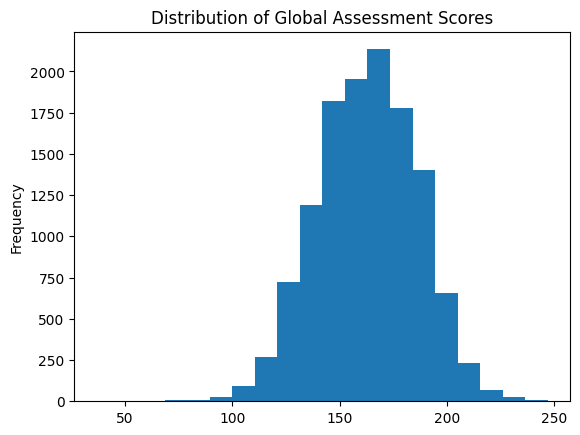

In [10]:
# Data visualization for G_SC (global score) to further examine its distribution
student_performance["G_SC"].plot(
    kind="hist",
    bins=20,
    title="Distribution of Global Assessment Scores"
)

This histogram of global assessment scores shows a roughly normal distribution. Most of the scores are concentrated around 150-180, with fewer students receiving very low or very high scores (fewer extreme values).

# **Step3: Interpret statistical results by group**

### **Question 1: Does parental education influence outcomes, and if so, how much?**

In [11]:
# Use global assessment score as the outcome, analyze the impact of mother's educational attainment
# on academic performance
mother_edu = (
    student_performance
    .groupby("EDU_MOTHER")["G_SC"]
    .agg(["count", "mean", "std", "median"])
    .sort_values("mean")
)

mother_edu.round(2)

,count,mean,std,median
EDU_MOTHER,,,,
Ninguno,34,149.71,27.93,152.5
Incomplete primary,541,154.85,21.64,155.0
0,388,154.93,19.95,155.0
Complete primary,713,155.34,22.01,155.0
Incomplete Secundary,1056,155.67,21.93,156.0
Complete Secundary,3106,158.47,21.95,159.0
Not sure,179,159.41,25.47,159.0
Incomplete technical or technological,341,161.88,20.74,164.0
Complete technique or technology,1495,163.24,21.94,163.0


<Axes: title={'center': "Average Global Score by Mother's Education"}, ylabel='EDU_MOTHER'>

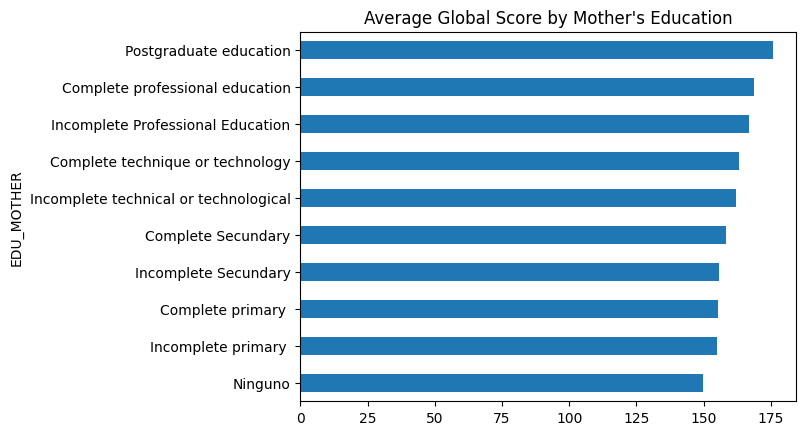

In [12]:
mother_plot = (
    student_performance[
        ~student_performance["EDU_MOTHER"].isin(["0", "Not sure"])
    ]
    .groupby("EDU_MOTHER")["G_SC"]
    .mean()
    .sort_values()
)

mother_plot.plot(
    kind="barh",
    title="Average Global Score by Mother's Education"
)

In [13]:
# Use global assessment score as the outcome, analyze the impact of father's educational attainment
# on academic performance
father_edu = (
    student_performance
    .groupby("EDU_FATHER")["G_SC"]
    .agg(["count", "mean", "std", "median"])
    .sort_values("mean")
)

father_edu.round(2)

,count,mean,std,median
EDU_FATHER,,,,
0,391,155.08,20.06,155.0
Complete primary,824,155.20,22.41,155.0
Incomplete primary,735,155.73,20.94,156.0
Incomplete Secundary,1091,156.54,21.74,157.0
Ninguno,123,156.63,23.19,159.0
Complete Secundary,2843,158.79,22.11,159.0
Not sure,407,160.29,22.94,159.0
Incomplete technical or technological,277,162.10,21.88,162.0
Complete technique or technology,1194,164.03,22.17,164.0


<Axes: title={'center': "Average Global Score by Father's Education"}, ylabel='EDU_FATHER'>

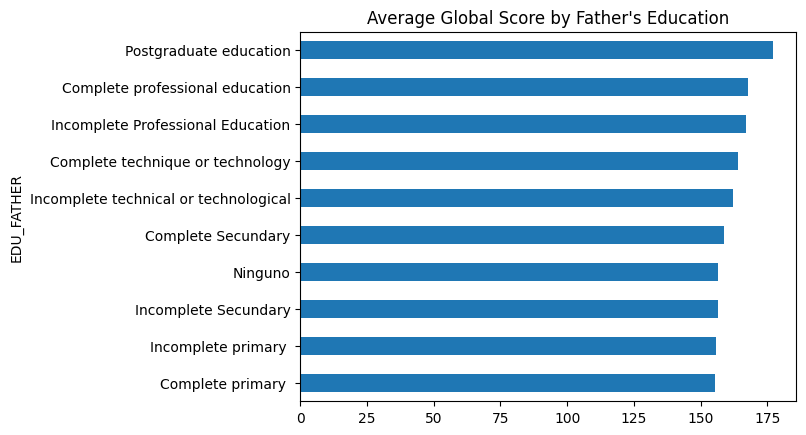

In [14]:
father_plot = (
    student_performance[
        ~student_performance["EDU_FATHER"].isin(["0", "Not sure"])
    ]
    .groupby("EDU_FATHER")["G_SC"]
    .mean()
    .sort_values()
)

father_plot.plot(
    kind="barh",
    title="Average Global Score by Father's Education"
)

Analysis:
As shown in both statistical results and barplots, I can conclude that parental education is positively associated with global assessment score. Specifically, there is a significant rise in students' score when parents receive education higher than 'complete professional education'. This pattern suggests that students from more educated households tend to have higher later academic outcomes. However, this is an association rather than direct evidence that parental education causes higher scores, so further analysis is necessary.

### **Question 2: Which stratum performs best academically?**

In [15]:
# examine how many levels the variable "STRATUM" has
student_performance["STRATUM"].value_counts()

,count
STRATUM,
Stratum 3,4045
Stratum 2,4029
Stratum 1,1709
Stratum 4,1578
Stratum 5,633
Stratum 6,403
0,14


In [16]:
# exclude 0 values
valid_stratum = student_performance[
    student_performance["STRATUM"] != "0"
]

In [17]:
# use global assessment score as DV and analyze by stratum subgroups
stratum_sum = (
    valid_stratum
    .groupby("STRATUM")["G_SC"]
    .agg(["count", "mean", "std", "median"])
)

stratum_sum.round(2)

,count,mean,std,median
STRATUM,,,,
Stratum 1,1709,152.35,21.94,152.0
Stratum 2,4029,158.20,22.28,158.0
Stratum 3,4045,163.82,21.69,164.0
Stratum 4,1578,172.00,21.47,174.0
Stratum 5,633,177.39,21.54,179.0
Stratum 6,403,181.51,21.88,184.0


Text(0.5, 0, 'Socioeconomic Stratum')

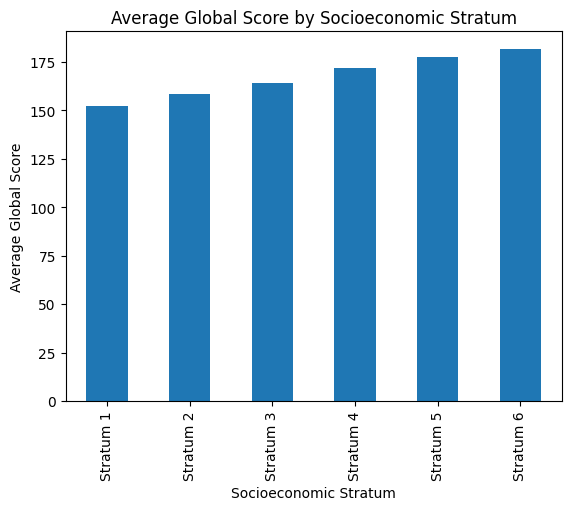

In [18]:
# visualize academic performance difference between stratum
diff_stratum = stratum_sum["mean"].plot(
    kind="bar",
    title="Average Global Score by Socioeconomic Stratum"
)

diff_stratum.set_ylabel("Average Global Score")
diff_stratum.set_xlabel("Socioeconomic Stratum")

Analysis: Stratum 6 has the highest mean global score at approximately 181.51, while Stratum 1 has the lowest at approximately 152.35. Average performance rises consistently from Stratum 1 through Stratum 6, indicating a positive association between socioeconomic status and academic performance.

### **Question 3: How does each gender perform in the global assessment?**

In [19]:
# Gender difference in global assessment score
gender_summary = (
    student_performance
    .groupby("GENDER")["G_SC"]
    .agg(["count", "mean", "std", "median"])
)

gender_summary.round(2)

,count,mean,std,median
GENDER,,,,
F,5043,161.28,22.33,162.0
M,7368,163.69,23.58,164.0


Male student score slightly higher than female students with mean 163.69>161.28. However, this statistical result can be deviated since the number of male engineering students is more than female engineering student by 46% ((7368-5043)/5043=0.46 (46%) ). With less student amount, the global assessment mean of female students can be more susceptible to extreme values than male students.

In [20]:
# Gender difference by subject
test_vars = [
    "MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11",
    "QR_PRO", "CR_PRO", "CC_PRO", "ENG_PRO", "WC_PRO"
]

gender_subject = (
    student_performance
    .groupby("GENDER")[test_vars]
    .mean()
)

gender_subject.round(2)

,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO
GENDER,,,,,,,,,,
F,61.93,60.9,59.96,62.27,61.45,71.89,61.34,58.57,66.53,56.62
M,65.96,60.7,61.22,65.10,62.04,81.20,62.79,59.61,68.16,51.71


In [21]:
# See if there is any representative difference value
gender_gap = (
    gender_subject.loc["M"]
    - gender_subject.loc["F"]
)

gender_gap.round(2)

,0
MAT_S11,4.02
CR_S11,-0.20
CC_S11,1.26
BIO_S11,2.83
ENG_S11,0.59
QR_PRO,9.31
CR_PRO,1.45
CC_PRO,1.03
ENG_PRO,1.63
WC_PRO,-4.91


<Axes: title={'center': 'Average Test Scores by Gender'}>

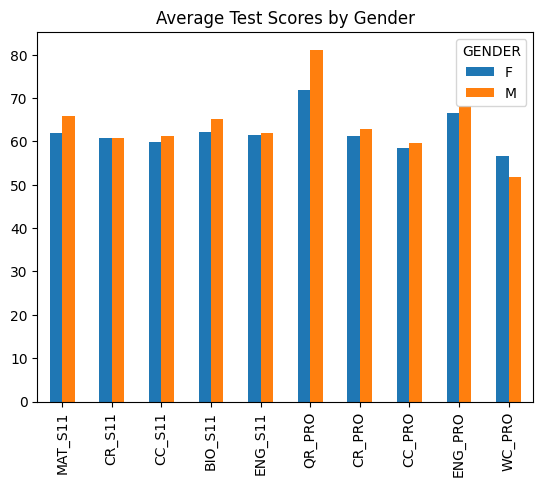

In [22]:
# visualize gender difference
gender_subject.T.plot(
    kind="bar",
    title="Average Test Scores by Gender"
)

Analysis: Although the gender gap in overall global score is relatively small, the score results grouped by subjects reveal larger differences. Male students score about 9.3 points higher in quantitative reasoning, whereas female students score about 4.9 points higher in written communication. This suggests that the global score (female students score slightly lower than male students) hides some meaningful subject-specific patterns.

### **Question 4: How do socioeconomic level (SEL) and institutional socioeconomic level (SEL_IHE) influence academic outcome?**

In [23]:
# how does socioeconomic level influence global score
sel_summary = (
    student_performance
    .groupby("SEL")["G_SC"]
    .agg(["count", "mean", "std", "median"])
)

sel_summary.round(2)

,count,mean,std,median
SEL,,,,
1,2138,155.47,21.80,155.0
2,4742,158.54,22.32,159.0
3,1491,162.30,22.02,162.0
4,4040,171.58,22.35,173.0


<Axes: title={'center': 'Average Global Score by Socioeconomic Level'}, xlabel='SEL'>

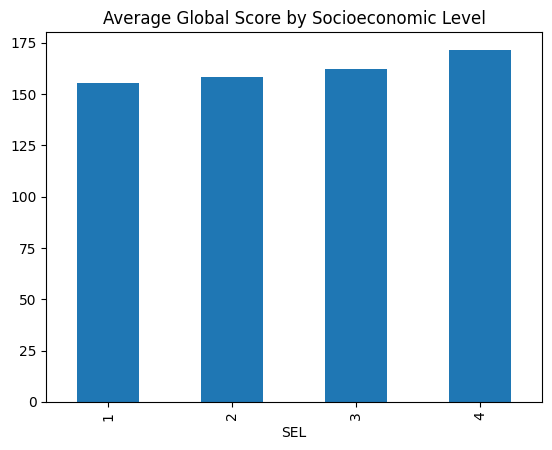

In [24]:
# visualization
sel_summary["mean"].plot(
    kind="bar",
    title="Average Global Score by Socioeconomic Level"
)

In [25]:
# how does socioeconomic level of institutions influence global score
sel_IHE_summary = (
    student_performance
    .groupby("SEL_IHE")["G_SC"]
    .agg(["count", "mean", "std", "median"])
)

sel_IHE_summary.round(2)

,count,mean,std,median
SEL_IHE,,,,
1,1137,153.14,20.61,153.0
2,7748,158.28,22.27,158.0
3,834,164.82,17.21,165.0
4,2692,178.85,20.18,180.0


<Axes: title={'center': 'Average Global Score by Institutional Socioeconomic Level'}, xlabel='SEL_IHE'>

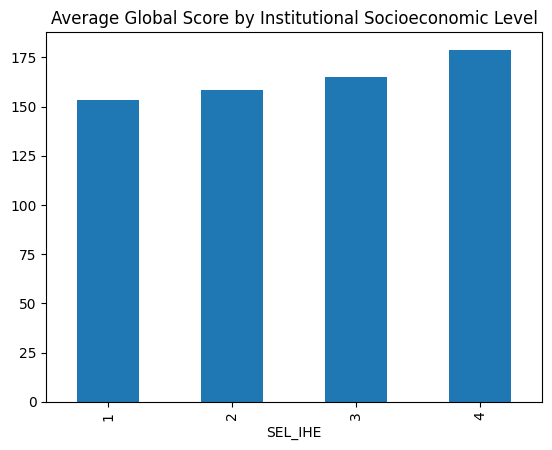

In [26]:
# visualization
sel_IHE_summary["mean"].plot(
    kind="bar",
    title="Average Global Score by Institutional Socioeconomic Level"
)

Analysis: Students attending institutions with higher socioeconomic levels also have higher average global scores. This is the same for students with higher socioeconomic levels. This suggests that both individual socioeconomic background and institutional context are associated with better academic outcomes.

### **Question 5: How does access to technology influence academic outcomes?**

In [27]:
#aggregate variables that indicate student has access to technology
tech_long = student_performance[
    ["G_SC", "INTERNET", "COMPUTER", "MOBILE"]
].melt(
    id_vars="G_SC",
    var_name="technology",
    value_name="access"
)

tech_long.head()

,G_SC,technology,access
0,180,INTERNET,Yes
1,182,INTERNET,Yes
2,113,INTERNET,No
3,157,INTERNET,Yes
4,198,INTERNET,Yes


In [28]:
tech_summary = (
    tech_long
    .groupby(["technology", "access"])["G_SC"]
    .agg(["count", "mean", "std", "median"])
)

tech_summary.round(2)

count    mean    std  median
technology access                              
COMPUTER   No       2237  155.95  21.86   156.0
           Yes     10174  164.20  23.12   165.0
INTERNET   No       2659  154.62  22.21   154.0
           Yes      9752  164.92  22.86   166.0
MOBILE     No       3564  155.51  22.41   155.0
           Yes      8847  165.61  22.75   166.0

In [29]:
# calculate global score mean based on technology groups
tech_means = (
    tech_long
    .groupby(["technology", "access"])["G_SC"]
    .mean()
    .unstack()
)

tech_means.round(2)

access,No,Yes
technology,,
COMPUTER,155.95,164.20
INTERNET,154.62,164.92
MOBILE,155.51,165.61


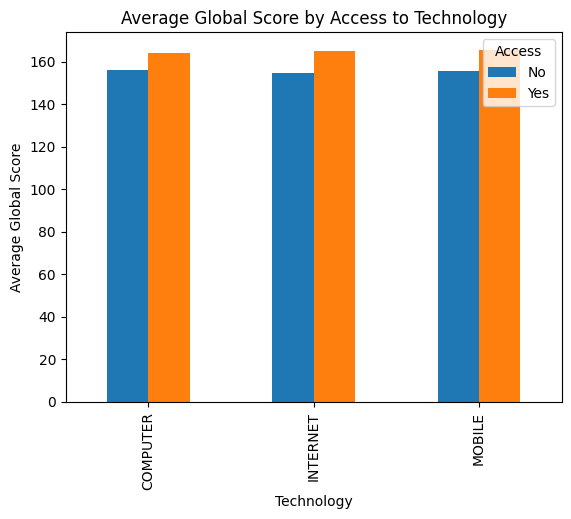

In [30]:
tech = tech_means.plot(
    kind="bar",
    title="Average Global Score by Access to Technology"
)

tech.set_xlabel("Technology")
tech.set_ylabel("Average Global Score")
tech.legend(title="Access")

Analysis: Access to technology is associated with higher academic performance across all four measures examined. Students with internet access have an average global score of 164.92, compared with 154.62 among students without internet access, a difference of approximately 10.30 points. A similar difference appears for mobile-phone access, where students with access score approximately 10.10 points higher. Similar trend for both access to computers and phones.

### **Question 6: How do prior academic performance (SABER 11), gender, stratum, parental education and access to technology together influence academic performance?**

In [31]:
import statsmodels.formula.api as smf

In [32]:
# Run regression model for all influencing factors
# here I exclude SEL and SEL_IHE since they overlap with STRATUM in measuring socioeconomic status of students
main_model = smf.ols(
    """
    G_SC ~ C(GENDER)
         + C(STRATUM)
         + C(EDU_MOTHER, Treatment(reference="Complete Secundary"))
         + C(EDU_FATHER, Treatment(reference="Complete Secundary"))
         + C(INTERNET)
         + C(COMPUTER)
         + C(MOBILE)
         + MAT_S11
         + CR_S11
         + CC_S11
         + BIO_S11
         + ENG_S11
    """,
    data=student_performance[
        student_performance["STRATUM"] != "0"
    ]
).fit()

print(main_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   G_SC   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     538.3
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        00:09:38   Log-Likelihood:                -50676.
No. Observations:               12397   AIC:                         1.014e+05
Df Residuals:                   12360   BIC:                         1.017e+05
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                                                                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

Interpretation

- **R^2**: The model explains approximately 61.1% of the variation in students' global assessment scores. The model as a whole is statistically significant.
- **Gender coefficient**: Holding socioeconomic stratum, parental education, technology access, and Saber 11 scores constant, male students are predicted to score about 0.36 points lower than female students on the global assessment. However, this difference is not statistically significant (p = 0.192). Comparing to previous analysis on how gender affects global score performance, the small raw gender difference in global scores largely disappears after accounting for socioeconomic characteristics and prior academic achievement.
- **Stratum coefficient**: Although, with reference to Stratum 1, Stratum 2, 3, and 4 have positive coefficients (0.73, 0.67, 0.71), none of their p-values is below 0.05, meaning that these results are not statistically significant. In other words, although students from higher socioeconomic strata had substantially higher global scores in the descriptive analysis, these differences were no longer statistically significant after controlling for prior Saber 11 performance and other background characteristics. This suggests that much of the raw relationship between socioeconomic stratum and later academic performance overlaps with differences in prior academic achievement and other family characteristics.
- **Parental education coefficient:** Most maternal and paternal education categories are not statistically significant after controlling for socioeconomic stratum, technology access, gender, and prior Saber 11 performance. This contrasts with the descriptive analysis, where students with more highly educated parents had noticeably higher average global scores. One exception is students whose mothers reported no education: their predicted G_SC is about 7.21 points lower than students whose mothers completed secondary education (p = 0.006), holding the other variables constant. Overall, the strong parental-education gradient observed descriptively becomes much weaker in the multivariable regression, suggesting that part of the raw relationship overlaps with prior academic achievement and other background characteristics.
- **Technology access coefficient**: Internet and mobile access remain statistically significant after controlling for the other variables. Students with internet access are predicted to score about 0.97 points higher than students without internet access (p = 0.017), while students with mobile access are predicted to score about 0.73 points higher (p = 0.036). In contrast, computer access has a very small coefficient of 0.11 and is not statistically significant (p = 0.795). Compared with the much larger raw differences observed in the descriptive analysis, these smaller adjusted coefficients suggest that much of the apparent technology gap is associated with socioeconomic conditions and prior academic performance.
- **Prior academic performance coefficients:** All five Saber 11 scores are positively and statistically significantly associated with later global assessment performance (p < 0.001 for all five variables). Holding the other variables constant, a one-point increase in Mathematics is associated with approximately 0.29 additional G_SC points, Critical Reading with 0.39 points, Citizen Competencies with 0.35 points, Biology with 0.35 points, and English with 0.46 points. These results show that students’ earlier academic performance has the most consistent relationship with their later global assessment scores among the variables included in the model.
- **Overall interpretation:** The regression results differ substantially from several of the descriptive findings. Gender, socioeconomic stratum, and most parental education categories show noticeable differences in the descriptive analysis but become statistically insignificant after other characteristics are controlled. Technology access also shows much smaller adjusted associations than its raw differences. In contrast, all five measures of prior academic achievement remain statistically significant. Therefore, the model suggests that prior Saber 11 performance is the most consistent predictor of later global academic performance, while many demographic and socioeconomic differences overlap with students’ earlier academic achievement and other background characteristics.